# Computer Vision with Convolutional Nueral Networks (CNN)
# CPSC 483 In-Class Exercise - CNN
#### (adapted from from Professsor Kyle Whynott's CPSC 483 course material and textbook:Hands-on Machine Learning by Geron)

### 0. Necessary Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import regularizers, layers

### 1. Frame the Problem



### Questions to Ask

1. What is the **Business Objective** in Building this Machine Learning Model?
    - **Goal:** To determine which articles of clothig sell the most
  
2. How does the company expect to use and benefit from this model?
    - Perhaps analyze the trends across fashion magazines, websites, blog, etc. and see what clothing trends the most when selling.

3. Performance Metrics Used
    - Primarily **Accuracy**, we are focused on correctly classifying the correct image to the correct label.
  
4. Assumptions Made
    1. Historical Data is Representative
       - The fradulent transaction data roughly reflects future fraudulent transaction data
    2. Labels are Mostly Correct
    3. Each Pixel is a Independent Observation of the image comprising of a larger 2D picture
    4. Image Classification in this task is a Multiclass Problem (0 - 9)

### 2. Get the Data

In [2]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()

In [3]:
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

In [4]:
X_train, X_valid, X_test = X_train.astype("float32") / 255.0 , X_valid.astype("float32") / 255.0 , X_test.astype("float32") / 255.0

### 3. Exploratory Data Analysis (EDA)

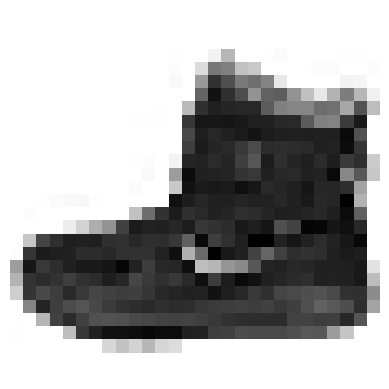

In [5]:
plt.imshow(X_train[0], cmap="binary")
plt.axis('off')
plt.show()

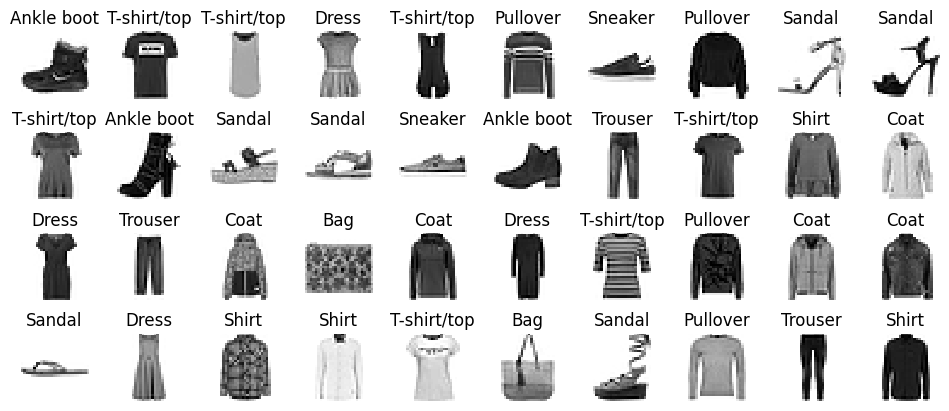

In [6]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(class_names[y_train[index]])
plt.subplots_adjust(wspace=0.2, hspace=0.5)


### 4. Prepare the Data and Model for Trainning

- The data is already prepared for us. Next, week we'll dive more into CNNs with a unprepared / dirty dataset
- We do; however, **need to create another channel dimension (axis) for the data to be perceived in 2D

In [7]:
# Adding Channel Dimension for CNN
X_train = X_train[..., tf.newaxis]
X_test = X_test[..., tf.newaxis]
X_valid = X_valid[..., tf.newaxis]

In [8]:
# Bonus: Monte Carlo (MC) Dropout Layer
class MCDropout(layers.Dropout):
    def call(self, inputs, training=True):
        return super().call(inputs, training=True)

In [9]:
tf.random.set_seed(42)

### 5. Select and Train the Model (and 6. Fine-Tune the Model)

In [10]:
# CNN with MonteCarlo (MC) Dropout, GELU Activation Function,
# Batch Normalization, and for Kernel Initialization (He_normalization)

# Seqeuential API
model = keras.Sequential()
# Input Layer
model.add(tf.keras.layers.InputLayer(shape=[28,28,1]))

# Block 1
model.add(tf.keras.layers.Conv2D(
    32, (3,3), padding="same",
    kernel_initializer="he_normal", # preventing vanishing gradients. Each filter’s weights are: randomly initialized,scaled properly based on input size
    kernel_regularizer=regularizers.l2(0.01)
))
model.add(tf.keras.layers.BatchNormalization())  # preventing vanishing gradients, normalize input to each layerr.
model.add(tf.keras.layers.Activation("gelu"))
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(MCDropout(0.25))


#To do
# Block 2
# 1. Add more convolutional layers with increasing filter sizes (e.g., 64) to capture more complex features.
# 2. Use Batch Normalization after each convolutional layer to stabilize and accelerate training.
# 3. Implement the GELU activation function for better performance.
# 4. Apply MaxPooling2D layers to reduce spatial dimensions and capture dominant features.
# 5. Add dropout layers (e.g., MCDropout) to prevent overfitting, especially after pooling layers.
model.add(tf.keras.layers.Conv2D(
    64, (3,3), padding='same',
    kernel_initializer='he_normal',
    kernel_regularizer=regularizers.l2(0.01)
))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Activation("gelu"))
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(MCDropout(0.25))


# Dense Head (Flatten Layer)
model.add(tf.keras.layers.Flatten())

# Dense Layer
model.add(tf.keras.layers.Dense(
    128,
    kernel_initializer="he_normal",
    kernel_regularizer=regularizers.l2(0.001))
)
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Activation("gelu"))
model.add(MCDropout(0.5))
# Output Layer
model.add(tf.keras.layers.Dense(10, activation="softmax"))

#### Optmizer: AdamW

In [11]:
optimizer = keras.optimizers.AdamW(
    learning_rate=0.001,
    weight_decay=0.0001    #L2-style regularization, penalty for large weight change, L_new = L_original + lambda * (w1² + w2² + w3² + ... + wn²)
)

#### Learning Rate Scheduling
ReduceLROnPlateau is a learning rate scheduler that:
- Watches a metric (usually validation loss)
- If that metric stops improving, it reduces the learning rate

In [12]:
lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)


### 7. Create, Evaluate, and Save the Finalized Model

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_dropout (MCDropout)          │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_dropout_1 (MCDropout)        │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_dropout_2 (MCDropout)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,538 (1.61 MB)

 Trainable params: 422,090 (1.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [14]:
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[lr_scheduler],
    validation_data=(X_valid, y_valid)
)


Epoch 1/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 292s 321ms/step - accuracy: 0.8217 - loss: 1.2631 - val_accuracy: 0.8460 - val_loss: 0.7348 - learning_rate: 0.0010
Epoch 2/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 243s 282ms/step - accuracy: 0.8645 - loss: 0.6221 - val_accuracy: 0.8692 - val_loss: 0.5908 - learning_rate: 0.0010
Epoch 3/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 249s 289ms/step - accuracy: 0.8731 - loss: 0.5692 - val_accuracy: 0.8612 - val_loss: 0.6027 - learning_rate: 0.0010
Epoch 4/20
694/860 ━━━━━━━━━━━━━━━━━━━━ 40s 243ms/step - accuracy: 0.8734 - loss: 0.5603

In [ ]:
pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 29], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left")  # extra code
plt.show()

In [ ]:
model.evaluate(X_test, y_test)

In [ ]:
# To do (Bonus +5):
# Copy the previous CNN code block and paste it below.
# Then, modify the architecture by adding Block 3 after Block 2. You can adjust the model parameters or even add more layers.
# After implementing it, briefly explain whether this change improves the model
# and why or why not.
# CNN with MonteCarlo (MC) Dropout, GELU Activation Function,
# Batch Normalization, and for Kernel Initialization (He_normalization)

# Seqeuential API
model = keras.Sequential()
# Input Layer
model.add(tf.keras.layers.InputLayer(shape=[28,28,1]))

# Block 1
model.add(tf.keras.layers.Conv2D(
    32, (3,3), padding="same",
    kernel_initializer="he_normal", # preventing vanishing gradients. Each filter’s weights are: randomly initialized,scaled properly based on input size
    kernel_regularizer=regularizers.l2(0.01)
))
model.add(tf.keras.layers.BatchNormalization())  # preventing vanishing gradients, normalize input to each layerr.
model.add(tf.keras.layers.Activation("gelu"))
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(MCDropout(0.25))


#To do
# Block 2
# 1. Add more convolutional layers with increasing filter sizes (e.g., 64) to capture more complex features.
# 2. Use Batch Normalization after each convolutional layer to stabilize and accelerate training.
# 3. Implement the GELU activation function for better performance.
# 4. Apply MaxPooling2D layers to reduce spatial dimensions and capture dominant features.
# 5. Add dropout layers (e.g., MCDropout) to prevent overfitting, especially after pooling layers.
model.add(tf.keras.layers.Conv2D(
    64, (3,3), padding='same',
    kernel_initializer='he_normal',
    kernel_regularizer=regularizers.l2(0.01)
))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Activation("gelu"))
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(MCDropout(0.25))


# Dense Head (Flatten Layer)
model.add(tf.keras.layers.Flatten())

# Dense Layer
model.add(tf.keras.layers.Dense(
    128,
    kernel_initializer="he_normal",
    kernel_regularizer=regularizers.l2(0.001))
)
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Activation("gelu"))
model.add(MCDropout(0.5))
# Output Layer
model.add(tf.keras.layers.Dense(10, activation="softmax"))

# Block 3
# 1. Add more convolutional layers with increasing filter sizes (e.g., 128) to capture more complex features.
# 2. Use Batch Normalization after each convolutional layer to stabilize and accelerate training.
# 3. Implement the GELU activation function for better performance.
# 4. Apply MaxPooling2D layers to reduce spatial dimensions and capture dominant features.
# 5. Add dropout layers (e.g., MCDropout) to prevent overfitting, especially after pooling layers.
model.add(tf.keras.layers.Dense(
    128,
    kernel_initializer="he_normal",
    kernel_regularizer=regularizers.l2(0.001))
)
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Activation("gelu"))
model.add(MCDropout(0.5))
# Output Layer
model.add(tf.keras.layers.Dense(10, activation="softmax"))


#### (To do) Discussion, it the model improved? why? or why not? (+5 pts)

Your Answer:

In [ ]:
model.save("../model/cnn_fashion_mnist.keras")